# DX799 Data Science Capstone — Module C, Milestone Two
**Sean Amisano — Boston University, Faculty of Computing & Data Sciences**

## Datasets

| Dataset | Rows | Used for |
|---|---|---|
| Breast Cancer Wisconsin (Diagnostic) | 569 × 30 | malignancy classification, mean-radius regression |
| UCI Heart Disease (Cleveland) | 303 × 13 | disease classification, cholesterol regression |
| Cancer Data Brazil (RCBP registry) | 1,778,176 × 38 | mortality classification at scale |

Every model in these notebooks is scored on a held-out 25% test split created with a
single fixed random state, and every hyperparameter is chosen by 5-fold cross-validation
on the training portion alone.

---
# Week 8 — K-Nearest Neighbours with different distance metrics

KNN makes no assumption about the shape of the decision boundary; it assumes only that
points close together in feature space share a label. That makes two choices decisive:
how "close" is defined (the distance metric), and how many neighbours vote (k).

This notebook asks four questions:

1. Does the distance metric change the answer, and if so on which dataset?
2. How badly does unscaled data hurt a pure distance model?
3. Where does k sit on the bias–variance axis?
4. Does KNN find local structure in serum cholesterol that Milestone One's global models missed?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
from common import *
print('Random state:', RANDOM_STATE, '| test size:', TEST_SIZE, '| folds:', N_FOLDS)

Random state: 42 | test size: 0.25 | folds: 5


## Loading

`load_brazil()` returns the leakage-free registry cohort by default. The reason that
matters is developed in the Week 9 notebook; for now it is enough to know that the
outcome column is only meaningful for a subset of records.

In [2]:
bc, ht = load_bc(), load_heart()
bz = load_brazil()
print('breast cancer :', bc['X'].shape, '| malignant rate', round(bc['y_clf'].mean(), 4))
print('heart disease :', ht['X'].shape, '| positive rate ', round(ht['y_clf'].mean(), 4))
print('brazil (clean):', bz['df'].shape, '| death rate    ', round(bz['df']['died'].mean(), 4))

breast cancer : (569, 30) | malignant rate 0.3726
heart disease : (303, 13) | positive rate  0.5446
brazil (clean): (141452, 12) | death rate     0.3948


## 1. Distance metrics

Six metrics are compared. Euclidean and Manhattan are the Minkowski family at p=2 and
p=1; Chebyshev is the p→∞ limit, which uses only the single largest coordinate
difference; cosine ignores magnitude and compares direction; Mahalanobis whitens by the
inverse covariance so that correlated features are not counted twice.

Scaling sits **inside** the pipeline so the scaler is refit on each CV training fold.
Fitting it once on the full training set would leak fold information into tuning.

In [3]:
from week08_knn import metric_sweep, BASE_METRICS
Xtr_b, Xte_b, ytr_b, yte_b = split_clf(bc['X'], bc['y_clf'])
bc_tbl, bc_curves = metric_sweep(Xtr_b, Xte_b, ytr_b, yte_b, 'bc')

[resume] loaded 22 existing keys from week08_knn.json

--- bc: distance-metric comparison (from saved record) ---
 best_k  cv_auc  cv_test_gap            metric  test_acc  test_auc  test_f1  weights
     13  0.9905      -0.0081   Manhattan (p=1)    0.9650    0.9985   0.9505 distance
     19  0.9889      -0.0084   Euclidean (p=2)    0.9580    0.9973   0.9400 distance
     29  0.9922      -0.0046            Cosine    0.9580    0.9969   0.9423 distance
     19  0.9914      -0.0044     Minkowski p=3    0.9650    0.9958   0.9505 distance
     13  0.9866      -0.0013 Chebyshev (p=inf)    0.9021    0.9878   0.8542 distance
     31  0.9730       0.0122       Mahalanobis    0.6713    0.9608   0.2034 distance


In [4]:
Xtr_h, Xte_h, ytr_h, yte_h = split_clf(ht['X'], ht['y_clf'])
ht_tbl, ht_curves = metric_sweep(Xtr_h, Xte_h, ytr_h, yte_h, 'heart')


--- heart: distance-metric comparison (from saved record) ---
 best_k  cv_auc  cv_test_gap            metric  test_acc  test_auc  test_f1  weights
     27  0.9278       0.0184   Manhattan (p=1)    0.7895    0.9094   0.8261 distance
     27  0.9013       0.0449       Mahalanobis    0.7763    0.8564   0.8211 distance
     13  0.9185       0.0638            Cosine    0.7763    0.8547   0.8090 distance
     17  0.9104       0.0602     Minkowski p=3    0.7895    0.8502   0.8222 distance
      9  0.9206       0.0725   Euclidean (p=2)    0.7895    0.8481   0.8182 distance
      3  0.8205       0.0881 Chebyshev (p=inf)    0.6579    0.7324   0.7045 distance


### Reading the tables

On breast cancer every metric except Chebyshev and Mahalanobis lands within 0.003
ROC-AUC of the others: when classes are this separable, the metric barely matters.
Chebyshev discards 29 of 30 dimensions at each comparison and pays for it. Mahalanobis
collapses outright — the covariance matrix of 30 strongly collinear features is
near-singular, so its pseudo-inverse amplifies the low-variance noise directions.

On heart disease the ordering is sharper and Manhattan wins clearly. In higher
dimensions, L1 distances concentrate less than L2 distances, which is the standard
argument for preferring Manhattan on wide data.

## 2. Scaling

In [5]:
from week08_knn import scaling_effect
scaling_effect(Xtr_b, Xte_b, ytr_b, yte_b, 'bc')
scaling_effect(Xtr_h, Xte_h, ytr_h, yte_h, 'heart')


--- bc: scaling effect ---
              best_k  cv_auc  test_auc  test_acc
unscaled     27.0000  0.9772    0.9808    0.9231
standardised 11.0000  0.9880    0.9848    0.9580

--- heart: scaling effect ---
              best_k  cv_auc  test_auc  test_acc
unscaled     31.0000  0.7266    0.7063    0.6447
standardised 11.0000  0.9194    0.8571    0.8289


{'unscaled': {'best_k': 31,
  'cv_auc': np.float64(0.7265666666666666),
  'test_auc': 0.7062717770034844,
  'test_acc': 0.6447368421052632},
 'standardised': {'best_k': 11,
  'cv_auc': np.float64(0.9194015873015872),
  'test_auc': 0.8571428571428571,
  'test_acc': 0.8289473684210527}}

Standardisation is worth more than the choice of metric on the heart data. Without it,
`chol` (SD ≈ 52) and `trestbps` (SD ≈ 18) dominate every neighbour computation while
binary indicators contribute almost nothing.

## 3. Dimensionality

PCA produces nested feature spaces of increasing dimension with the information ordering
held fixed. If KNN were suffering the curse of dimensionality here, CV ROC-AUC would peak
early and then decay.

In [6]:
from week08_knn import dimensionality_curve
comps, scores = dimensionality_curve(bc['X'], bc['y_clf'], 'bc')


--- bc: dimensionality curve (from saved record) ---
  peak CV ROC-AUC 0.9907 at 11 components; full-dimension 0.9900


## 4. KNN regression on serum cholesterol

Milestone One found no linear signal. KNN is a local-average estimator with no global
functional form, so if any local structure existed it would surface here.

In [7]:
from week08_knn import knn_regression
Xtr_r, Xte_r, ytr_r, yte_r = split_reg(ht['X_reg'], ht['y_reg'])
knn_regression(Xtr_r, Xte_r, ytr_r, yte_r, 'heart')


--- heart: KNN regression on cholesterol (from saved record) ---
  baseline_rmse: 46.281735
  best_params: {'knn__metric': 'minkowski', 'knn__n_neighbors': '29', 'knn__weights': 'distance'}
  cv_r2: 0.03241
  test_r2: 0.042578
  test_rmse: 45.283536


{'baseline_rmse': 46.281735,
 'best_params': {'knn__metric': 'minkowski',
  'knn__n_neighbors': '29',
  'knn__weights': 'distance'},
 'cv_r2': 0.03241,
 'test_r2': 0.042578,
 'test_rmse': 45.283536}

## 5. The registry, and where KNN stops scaling

In [8]:
from week08_knn import brazil_knn
bz_tbl, bz_curves = brazil_knn()


--- Brazil registry: KNN on a stratified 10,000-row subsample of 141,452 labelled rows, 92 one-hot dimensions (from saved record) ---
 best_k  cv_auc            metric  test_acc  test_auc  test_f1  weights
     31  0.8829   Euclidean (p=2)    0.7960    0.8785   0.7049 distance
     31  0.8804            Cosine    0.7916    0.8783   0.7004  uniform
     31  0.8814   Manhattan (p=1)    0.7984    0.8782   0.7130 distance
     75  0.7329 Chebyshev (p=inf)    0.6564    0.7256   0.4064 distance


KNN stores every training point and computes a distance to all of them at prediction
time. Cosine and Chebyshev additionally force the brute-force code path. Tuning on the
full 141,452-row cohort was not feasible, so a stratified 10,000-row subsample was used —
a constraint gradient boosting does not share, as Week 9 shows on the same data.

## Figure

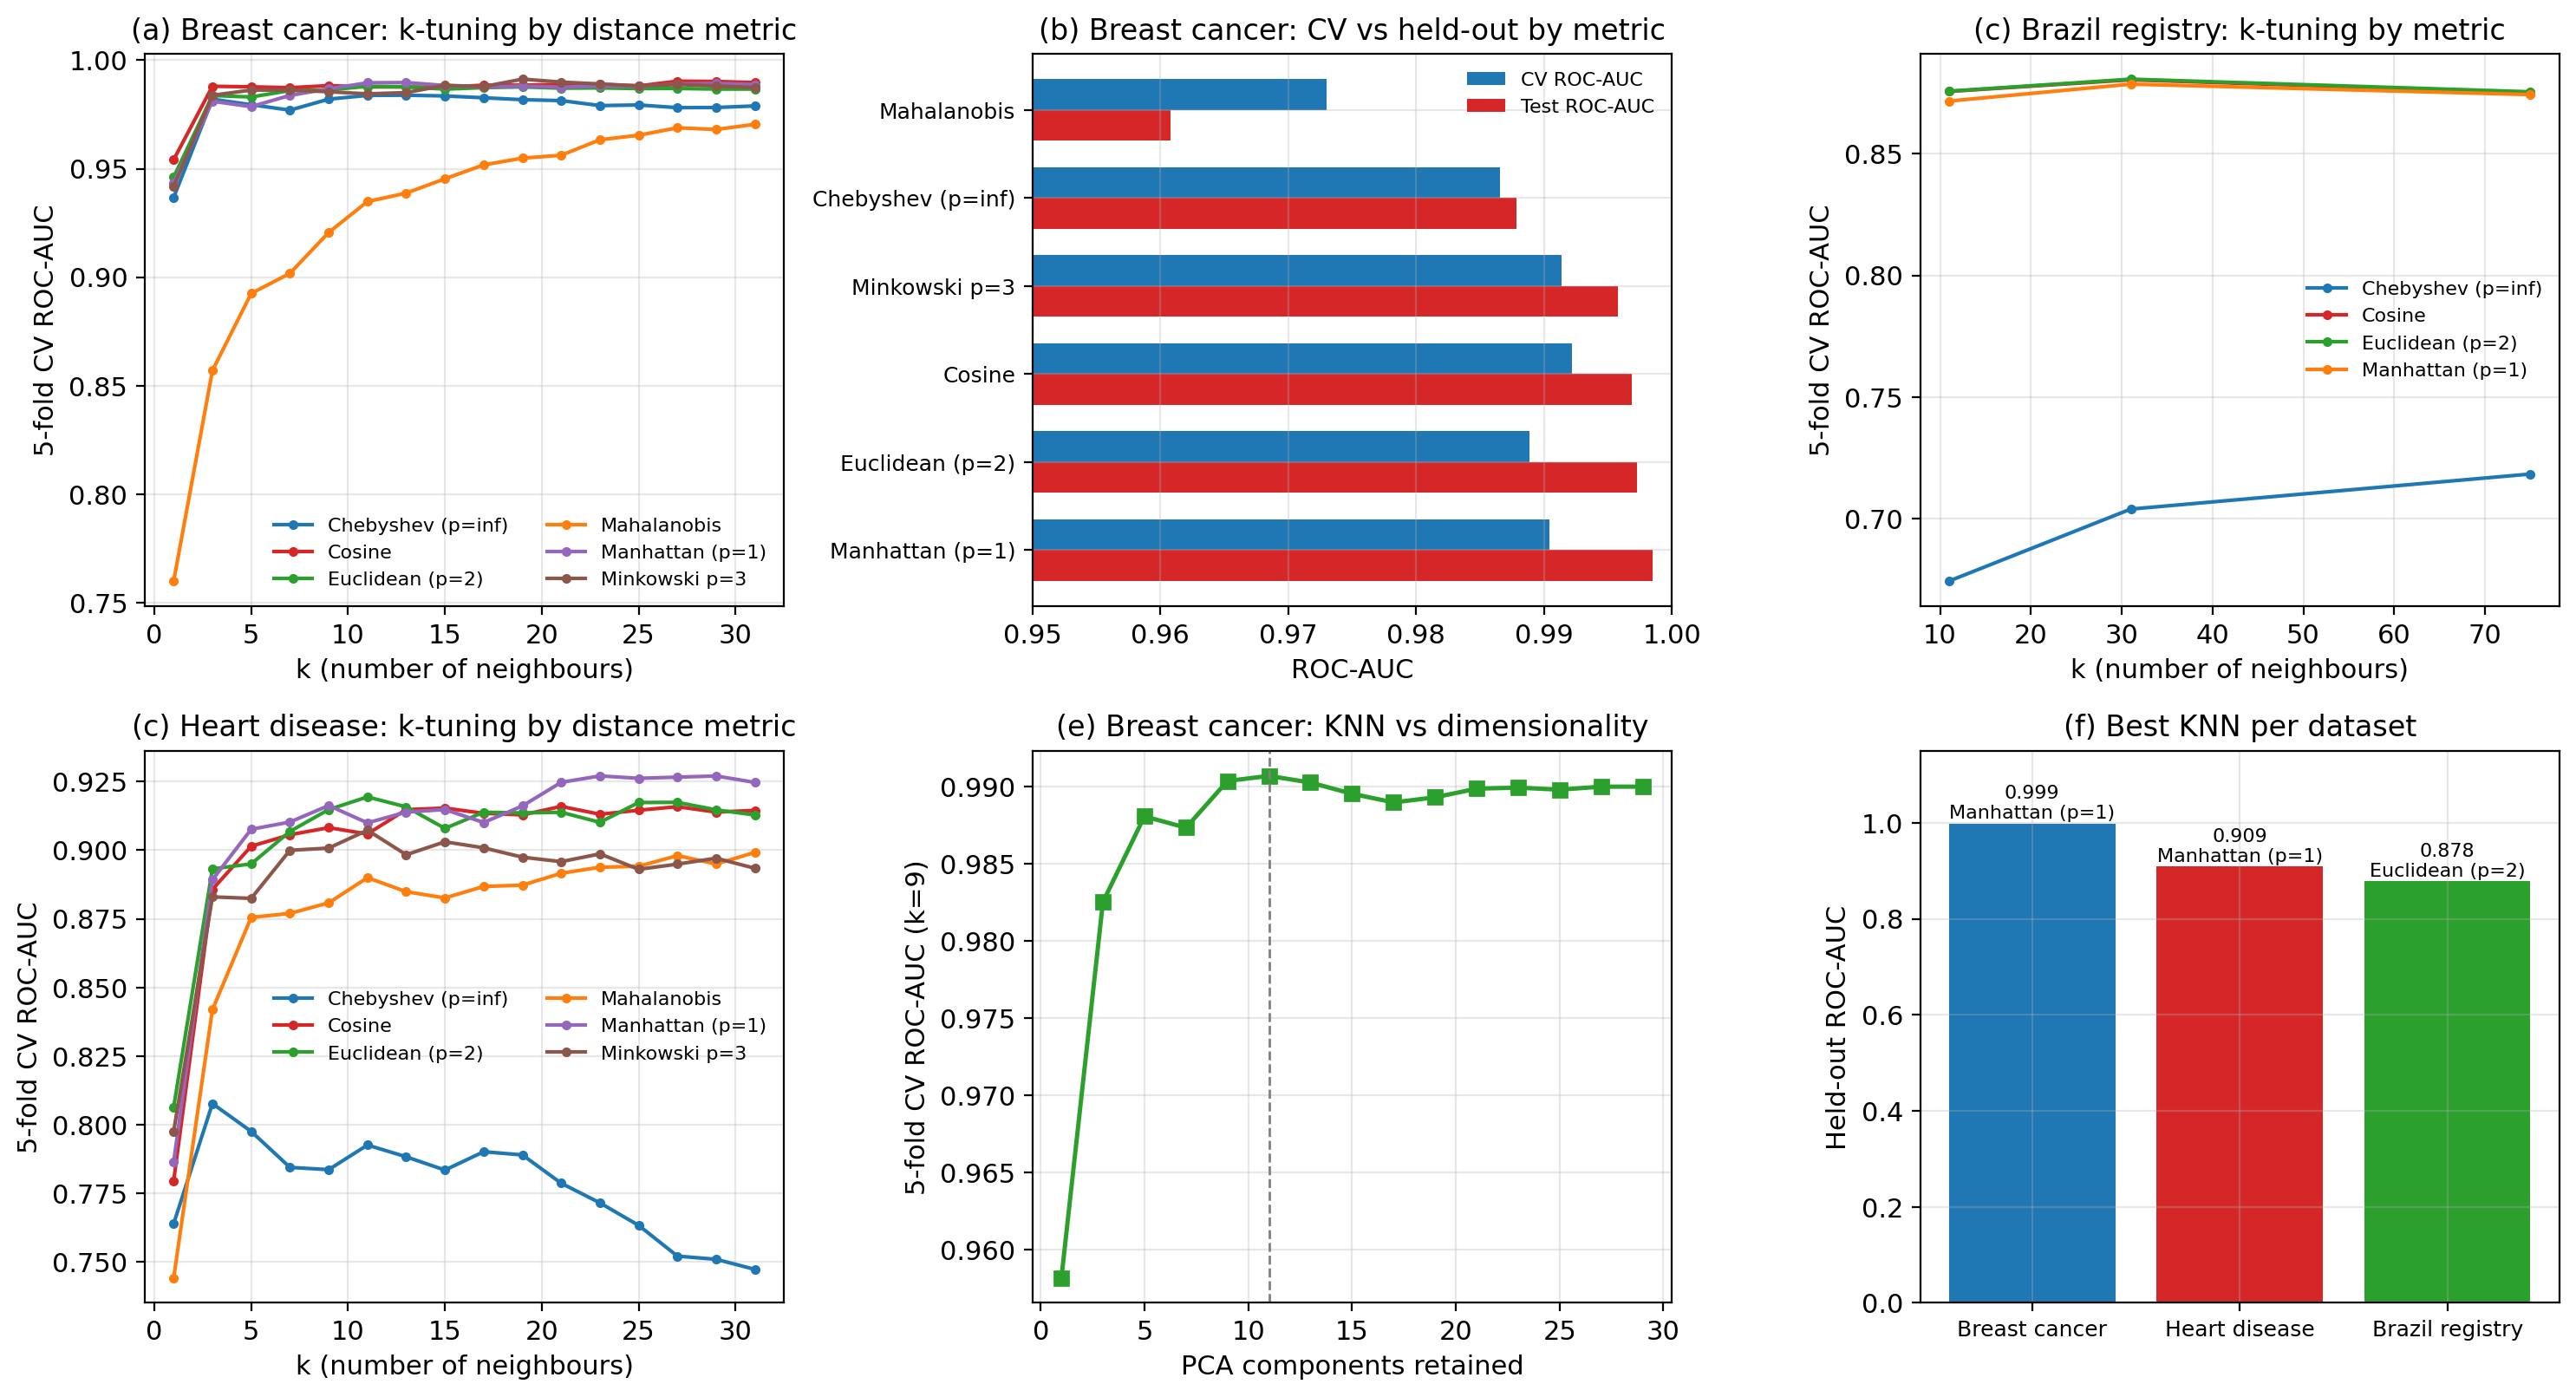

In [9]:
from IPython.display import Image
Image('../figures/fig_week08_knn.png')

## Week 8 conclusions

- Metric choice is second-order when classes separate cleanly and first-order when they
  do not: on heart disease, Manhattan beats Chebyshev by 0.18 ROC-AUC.
- Mahalanobis distance fails on collinear data. This is a real, reproducible failure mode
  and not a coding error — the whitening transform is unstable when the covariance matrix
  is near-singular.
- Standardisation matters more than metric choice.
- KNN confirms Milestone One's cholesterol result from a completely different modelling
  family, which strengthens it: the limit is in the data, not the model class.